# Customer Review Intelligence System
## Notebook 02 — Model Training

**Model:** `distilbert-base-uncased` fine-tuned for 3-class sentiment classification  
**Dataset:** Yelp Review Full — 96K train / 12K val / 12K test (balanced, pre-split by 01_eda.ipynb)  
**Labels:** `0 = Negative` · `1 = Neutral` · `2 = Positive`  
**max_length:** 256 tokens (covers ~77% of reviews fully; deliberate speed/coverage tradeoff)  

**Run environment:** Kaggle — enable GPU before running (Settings → Accelerator → GPU T4 x1)

**Before running:**
1. Upload `data/train.csv`, `data/val.csv`, `data/test.csv` as a Kaggle Dataset
2. Attach that dataset to this notebook (+ Add Data → Your Datasets)
3. Enable GPU accelerator
4. Set `KAGGLE_DATA_PATH` in Cell 2 to match your dataset path

**Expected runtime:** ~40–50 minutes on Kaggle T4 GPU

---

## 0. Install dependencies

In [3]:
# Kaggle has most packages pre-installed; install anything missing
!pip install -q transformers datasets accelerate scikit-learn

> **Note:** A PEFT–Transformers compatibility issue in the Kaggle environment prevented `Trainer` from importing. Since this project uses standard DistilBERT fine-tuning (not LoRA/PEFT), uninstalling `peft` resolved the issue without affecting training.

In [2]:
!pip uninstall -y peft

Found existing installation: peft 0.18.1
Uninstalling peft-0.18.1:
  Successfully uninstalled peft-0.18.1


## 1. Imports and configuration

In [4]:
from transformers import (
    AutoTokenizer,
    AutoModelForSequenceClassification,
)

tokenizer = AutoTokenizer.from_pretrained("distilbert-base-uncased")

model = AutoModelForSequenceClassification.from_pretrained(
    "distilbert-base-uncased",
    num_labels=3
)

print("Tokenizer loaded")
print("Model loaded")

config.json:   0%|          | 0.00/483 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

model.safetensors:   0%|          | 0.00/268M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_layer_norm.bias   | UNEXPECTED | 
vocab_transform.bias    | UNEXPECTED | 
vocab_transform.weight  | UNEXPECTED | 
vocab_layer_norm.weight | UNEXPECTED | 
vocab_projector.bias    | UNEXPECTED | 
classifier.weight       | MISSING    | 
pre_classifier.bias     | MISSING    | 
pre_classifier.weight   | MISSING    | 
classifier.bias         | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Tokenizer loaded
Model loaded


In [5]:
import os
import json
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import torch

from transformers import (
    AutoTokenizer,
    AutoModelForSequenceClassification,
    TrainingArguments,
    Trainer,
    EarlyStoppingCallback,
    DataCollatorWithPadding,
)
from datasets import Dataset, DatasetDict
from sklearn.metrics import (
    accuracy_score,
    f1_score,
    classification_report,
    confusion_matrix,
)
import matplotlib.pyplot as plt
import seaborn as sns

# ── Configuration ─────────────────────────────────────────────────────────────
# Update this path to match your attached Kaggle dataset location
KAGGLE_DATA_PATH = '/kaggle/input/datasets/dhairyatipandya/customer-dataset'   # <-- change if needed

MODEL_NAME    = 'distilbert-base-uncased'
MAX_LENGTH    = 256
BATCH_SIZE    = 16
NUM_EPOCHS    = 3
LEARNING_RATE = 2e-5
WARMUP_RATIO  = 0.1        # 10% of total steps used for linear warmup
WEIGHT_DECAY  = 0.01
SEED          = 42

OUTPUT_DIR    = '/kaggle/working/distilbert-sentiment'
LOGS_DIR      = '/kaggle/working/logs'

ID2LABEL = {0: 'Negative', 1: 'Neutral', 2: 'Positive'}
LABEL2ID = {'Negative': 0, 'Neutral': 1, 'Positive': 2}

# ── Verify GPU ────────────────────────────────────────────────────────────────
device = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f'Device       : {device}')
if device == 'cuda':
    print(f'GPU          : {torch.cuda.get_device_name(0)}')
    print(f'VRAM total   : {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB')
else:
    print('WARNING: No GPU detected. Training will be very slow on CPU.')
    print('Go to Kaggle Settings → Accelerator → GPU T4 x1')

print(f'\nTorch version      : {torch.__version__}')
print(f'Model              : {MODEL_NAME}')
print(f'Max sequence length: {MAX_LENGTH}')
print(f'Batch size         : {BATCH_SIZE}')
print(f'Epochs             : {NUM_EPOCHS}')
print(f'Learning rate      : {LEARNING_RATE}')

Device       : cuda
GPU          : Tesla T4
VRAM total   : 15.6 GB

Torch version      : 2.10.0+cu128
Model              : distilbert-base-uncased
Max sequence length: 256
Batch size         : 16
Epochs             : 3
Learning rate      : 2e-05


## 2. Load data

In [6]:
train_path = os.path.join(KAGGLE_DATA_PATH, 'train.csv')
val_path   = os.path.join(KAGGLE_DATA_PATH, 'val.csv')
test_path  = os.path.join(KAGGLE_DATA_PATH, 'test.csv')

# Verify files exist
for p in [train_path, val_path, test_path]:
    if not os.path.exists(p):
        raise FileNotFoundError(
            f'{p} not found.\n'
            f'Attach your dataset and update KAGGLE_DATA_PATH in Cell 1.'
        )

df_train = pd.read_csv(train_path)
df_val   = pd.read_csv(val_path)
df_test  = pd.read_csv(test_path)

# Sanity checks
for name, df in [('train', df_train), ('val', df_val), ('test', df_test)]:
    assert 'text'     in df.columns, f'{name}.csv missing "text" column'
    assert 'label_id' in df.columns, f'{name}.csv missing "label_id" column'
    assert df.isnull().sum().sum() == 0, f'{name}.csv contains null values'
    assert set(df['label_id'].unique()).issubset({0, 1, 2}), f'{name}.csv has unexpected label values'

print(f'Train : {len(df_train):>7,} rows')
print(f'Val   : {len(df_val):>7,} rows')
print(f'Test  : {len(df_test):>7,} rows')
print(f'\nTrain class distribution:')
print(df_train['label_id'].map(ID2LABEL).value_counts())

Train :  96,000 rows
Val   :  12,000 rows
Test  :  12,000 rows

Train class distribution:
label_id
Positive    32000
Neutral     32000
Negative    32000
Name: count, dtype: int64


## 3. Tokenize

In [7]:
print(f'Loading tokenizer: {MODEL_NAME}')
tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)

def tokenize(batch):
    """Tokenize a batch of texts with truncation and padding to MAX_LENGTH."""
    return tokenizer(
        batch['text'],
        truncation=True,
        max_length=MAX_LENGTH,
        padding=False,   # DataCollatorWithPadding handles per-batch dynamic padding
    )

# Convert to HuggingFace Dataset objects
def df_to_hf_dataset(df):
    return Dataset.from_dict({
        'text'  : df['text'].tolist(),
        'labels': df['label_id'].tolist(),
    })

raw_datasets = DatasetDict({
    'train': df_to_hf_dataset(df_train),
    'val'  : df_to_hf_dataset(df_val),
    'test' : df_to_hf_dataset(df_test),
})

print('Tokenizing... (this takes ~3–5 minutes)')
tokenized = raw_datasets.map(
    tokenize,
    batched=True,
    batch_size=512,
    remove_columns=['text'],
)
tokenized.set_format('torch')

print('\nTokenization complete.')
print(f'Train features : {tokenized["train"].features}')
print(f'\nSample token lengths (first 10 train examples):')
sample_lens = [len(tokenized['train'][i]['input_ids']) for i in range(10)]
print(sample_lens)

Loading tokenizer: distilbert-base-uncased
Tokenizing... (this takes ~3–5 minutes)


Map:   0%|          | 0/96000 [00:00<?, ? examples/s]

Map:   0%|          | 0/12000 [00:00<?, ? examples/s]

Map:   0%|          | 0/12000 [00:00<?, ? examples/s]


Tokenization complete.
Train features : {'labels': Value('int64'), 'input_ids': List(Value('int32')), 'token_type_ids': List(Value('int8')), 'attention_mask': List(Value('int8'))}

Sample token lengths (first 10 train examples):
[161, 26, 102, 30, 150, 256, 62, 62, 49, 86]


## 4. Load model

In [8]:
print(f'Loading model: {MODEL_NAME} with {len(ID2LABEL)} output classes')

model = AutoModelForSequenceClassification.from_pretrained(
    MODEL_NAME,
    num_labels=3,
    id2label=ID2LABEL,
    label2id=LABEL2ID,
)

total_params     = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)

print(f'Total parameters    : {total_params:,}')
print(f'Trainable parameters: {trainable_params:,}')
print(f'Model on device     : {device}')

Loading model: distilbert-base-uncased with 3 output classes


Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_layer_norm.bias   | UNEXPECTED | 
vocab_transform.bias    | UNEXPECTED | 
vocab_transform.weight  | UNEXPECTED | 
vocab_layer_norm.weight | UNEXPECTED | 
vocab_projector.bias    | UNEXPECTED | 
classifier.weight       | MISSING    | 
pre_classifier.bias     | MISSING    | 
pre_classifier.weight   | MISSING    | 
classifier.bias         | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Total parameters    : 66,955,779
Trainable parameters: 66,955,779
Model on device     : cuda


## 5. Metrics function

In [9]:
def compute_metrics(eval_pred):
    """
    Called by Trainer after each evaluation step.
    Reports accuracy and macro F1 — macro F1 is the primary metric
    because it weights all three classes equally regardless of frequency.
    """
    logits, labels = eval_pred
    predictions = np.argmax(logits, axis=1)

    acc      = accuracy_score(labels, predictions)
    macro_f1 = f1_score(labels, predictions, average='macro')
    pos_f1   = f1_score(labels, predictions, average=None, labels=[2])[0]
    neu_f1   = f1_score(labels, predictions, average=None, labels=[1])[0]
    neg_f1   = f1_score(labels, predictions, average=None, labels=[0])[0]

    return {
        'accuracy'       : round(acc,      4),
        'macro_f1'       : round(macro_f1, 4),
        'positive_f1'    : round(pos_f1,   4),
        'neutral_f1'     : round(neu_f1,   4),
        'negative_f1'    : round(neg_f1,   4),
    }

print('compute_metrics defined.')

compute_metrics defined.


## 6. Training arguments

In [10]:
# Total training steps — used to calculate warmup steps
steps_per_epoch = len(tokenized['train']) // BATCH_SIZE
total_steps     = steps_per_epoch * NUM_EPOCHS
warmup_steps    = int(total_steps * WARMUP_RATIO)

print(f'Steps per epoch : {steps_per_epoch:,}')
print(f'Total steps     : {total_steps:,}')
print(f'Warmup steps    : {warmup_steps:,}')

training_args = TrainingArguments(
    output_dir                  = OUTPUT_DIR,
    logging_dir                 = LOGS_DIR,

    # Core hyperparameters
    num_train_epochs            = NUM_EPOCHS,
    per_device_train_batch_size = BATCH_SIZE,
    per_device_eval_batch_size  = BATCH_SIZE * 2,  # larger eval batch — no gradients
    learning_rate               = LEARNING_RATE,
    weight_decay                = WEIGHT_DECAY,
    warmup_steps                = warmup_steps,
    lr_scheduler_type           = 'linear',

    # Evaluation and saving
    eval_strategy               = 'epoch',
    save_strategy               = 'epoch',
    load_best_model_at_end      = True,
    metric_for_best_model       = 'macro_f1',   # macro F1, not accuracy
    greater_is_better           = True,

    # Logging
    logging_steps               = 100,
    report_to                   = 'none',        # no wandb/tensorboard needed

    # Reproducibility
    seed                        = SEED,
    data_seed                   = SEED,

    # Performance
    fp16                        = (device == 'cuda'),  # mixed precision on GPU only
    dataloader_num_workers      = 2,
)

print('\nTrainingArguments configured.')

Steps per epoch : 6,000
Total steps     : 18,000
Warmup steps    : 1,800


`logging_dir` is deprecated and will be removed in v5.2. Please set `TENSORBOARD_LOGGING_DIR` instead.



TrainingArguments configured.


## 7. Train

In [11]:
data_collator = DataCollatorWithPadding(tokenizer=tokenizer)

trainer = Trainer(
    model           = model,
    args            = training_args,
    train_dataset   = tokenized['train'],
    eval_dataset    = tokenized['val'],
    data_collator   = data_collator,
    compute_metrics = compute_metrics,
    callbacks       = [EarlyStoppingCallback(early_stopping_patience=2)],
)

print('Starting training...')
print(f'Model: {MODEL_NAME}')
print(f'Epochs: {NUM_EPOCHS}  |  Batch: {BATCH_SIZE}  |  LR: {LEARNING_RATE}')
print(f'Estimated time: ~40–50 minutes on Kaggle T4\n')

train_result = trainer.train()

print('\nTraining complete.')
print(f'Total training time : {train_result.metrics["train_runtime"]:.0f} seconds')
print(f'Samples per second  : {train_result.metrics["train_samples_per_second"]:.1f}')

Starting training...
Model: distilbert-base-uncased
Epochs: 3  |  Batch: 16  |  LR: 2e-05
Estimated time: ~40–50 minutes on Kaggle T4



Epoch,Training Loss,Validation Loss,Accuracy,Macro F1,Positive F1,Neutral F1,Negative F1
1,1.082206,1.033980,0.771800,0.770200,0.821000,0.668300,0.821300
2,0.910262,1.008836,0.786400,0.788900,0.839100,0.711100,0.816500
3,0.712902,1.040696,0.791300,0.791900,0.837800,0.703500,0.834200


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

There were missing keys in the checkpoint model loaded: ['distilbert.embeddings.LayerNorm.weight', 'distilbert.embeddings.LayerNorm.bias'].
There were unexpected keys in the checkpoint model loaded: ['distilbert.embeddings.LayerNorm.beta', 'distilbert.embeddings.LayerNorm.gamma'].



Training complete.
Total training time : 3823 seconds
Samples per second  : 75.3


## 8. Evaluate on validation set

In [12]:
print('Evaluating on validation set...')
val_metrics = trainer.evaluate(tokenized['val'])

print('\nValidation results:')
print(f'  Accuracy    : {val_metrics["eval_accuracy"]:.4f}')
print(f'  Macro F1    : {val_metrics["eval_macro_f1"]:.4f}')
print(f'  Positive F1 : {val_metrics["eval_positive_f1"]:.4f}')
print(f'  Neutral F1  : {val_metrics["eval_neutral_f1"]:.4f}')
print(f'  Negative F1 : {val_metrics["eval_negative_f1"]:.4f}')

Evaluating on validation set...



Validation results:
  Accuracy    : 0.7913
  Macro F1    : 0.7919
  Positive F1 : 0.8378
  Neutral F1  : 0.7035
  Negative F1 : 0.8342


## 9. Evaluate on test set

Test set is evaluated **once**, here, after training is complete.  
These are the numbers reported in the README and on the resume.

In [13]:
print('Running final evaluation on held-out test set...')
predictions_output = trainer.predict(tokenized['test'])

logits      = predictions_output.predictions
true_labels = predictions_output.label_ids
pred_labels = np.argmax(logits, axis=1)

# Full classification report
print('\n' + '='*60)
print('FINAL TEST SET RESULTS')
print('='*60)
print(classification_report(
    true_labels,
    pred_labels,
    target_names=['Negative', 'Neutral', 'Positive'],
    digits=4
))

test_acc      = accuracy_score(true_labels, pred_labels)
test_macro_f1 = f1_score(true_labels, pred_labels, average='macro')
print(f'Overall accuracy : {test_acc:.4f}')
print(f'Macro F1         : {test_macro_f1:.4f}')

Running final evaluation on held-out test set...

FINAL TEST SET RESULTS
              precision    recall  f1-score   support

    Negative     0.8399    0.8277    0.8338      4000
     Neutral     0.6886    0.7127    0.7005      4000
    Positive     0.8479    0.8305    0.8391      4000

    accuracy                         0.7903     12000
   macro avg     0.7922    0.7903    0.7911     12000
weighted avg     0.7922    0.7903    0.7911     12000

Overall accuracy : 0.7903
Macro F1         : 0.7911


## 10. Confusion matrix

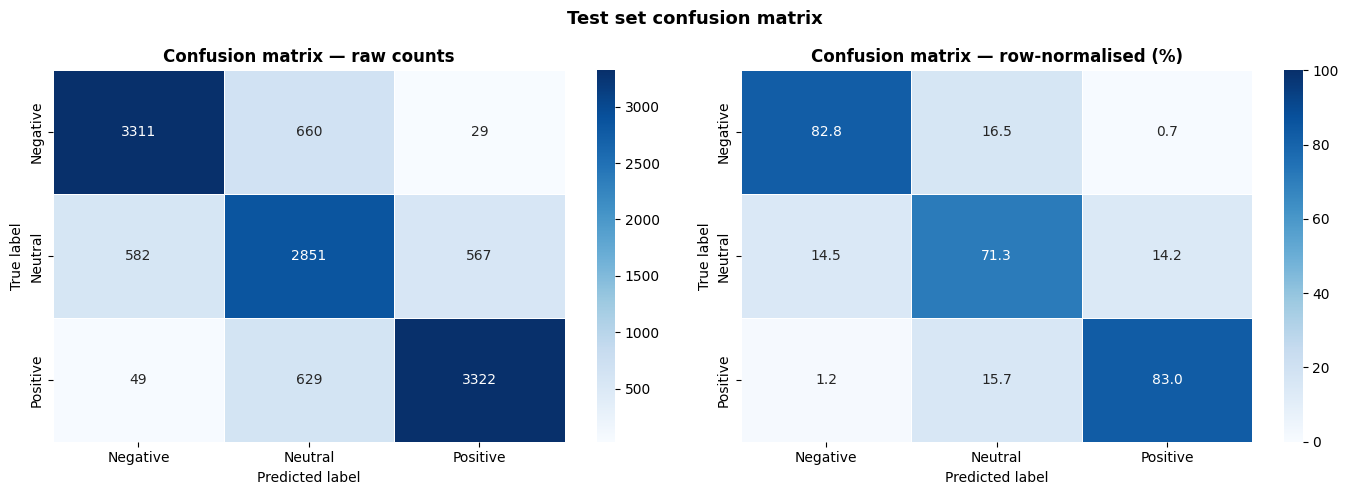

Observation: Check diagonal for per-class accuracy.
Neutral will have the lowest diagonal value — this is expected.


In [14]:
cm = confusion_matrix(true_labels, pred_labels)
cm_pct = cm.astype(float) / cm.sum(axis=1, keepdims=True) * 100

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
labels = ['Negative', 'Neutral', 'Positive']

# Raw counts
sns.heatmap(
    cm, annot=True, fmt='d', cmap='Blues',
    xticklabels=labels, yticklabels=labels,
    linewidths=0.5, ax=axes[0]
)
axes[0].set_title('Confusion matrix — raw counts', fontweight='bold')
axes[0].set_xlabel('Predicted label')
axes[0].set_ylabel('True label')

# Row-normalised percentages
sns.heatmap(
    cm_pct, annot=True, fmt='.1f', cmap='Blues',
    xticklabels=labels, yticklabels=labels,
    linewidths=0.5, ax=axes[1],
    vmin=0, vmax=100
)
axes[1].set_title('Confusion matrix — row-normalised (%)', fontweight='bold')
axes[1].set_xlabel('Predicted label')
axes[1].set_ylabel('True label')

plt.suptitle('Test set confusion matrix', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('/kaggle/working/confusion_matrix.png', bbox_inches='tight')
plt.show()

print('Observation: Check diagonal for per-class accuracy.')
print('Neutral will have the lowest diagonal value — this is expected.')

## 11. Training curve

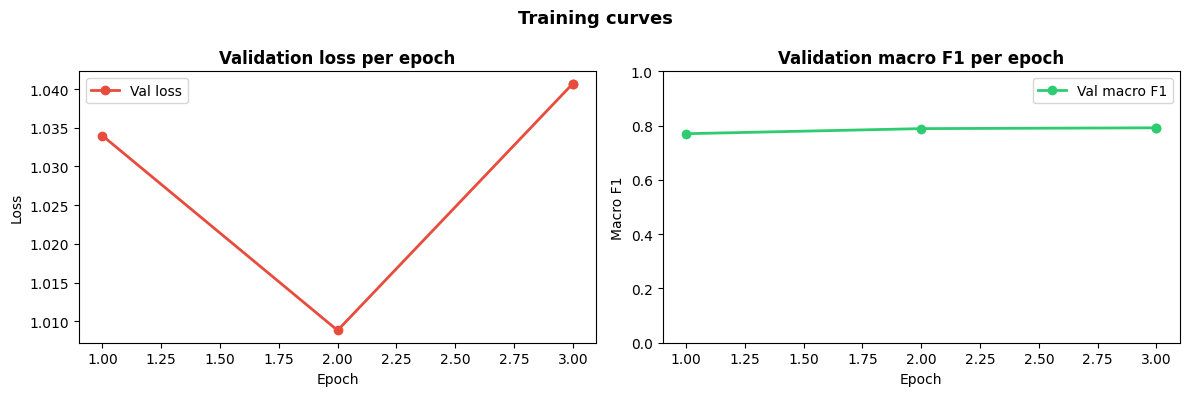

In [15]:
# Extract loss and macro F1 per epoch from trainer log history
log_history = trainer.state.log_history

train_loss, eval_loss, eval_macro_f1 = [], [], []
epochs_recorded = []

for entry in log_history:
    if 'eval_loss' in entry:
        eval_loss.append(entry['eval_loss'])
        eval_macro_f1.append(entry.get('eval_macro_f1', None))
        epochs_recorded.append(entry['epoch'])
    if 'loss' in entry and 'eval_loss' not in entry:
        train_loss.append(entry['loss'])

if eval_loss:
    fig, axes = plt.subplots(1, 2, figsize=(12, 4))

    axes[0].plot(epochs_recorded, eval_loss, marker='o', color='#e74c3c', linewidth=2, label='Val loss')
    axes[0].set_title('Validation loss per epoch', fontweight='bold')
    axes[0].set_xlabel('Epoch')
    axes[0].set_ylabel('Loss')
    axes[0].legend()

    if any(v is not None for v in eval_macro_f1):
        axes[1].plot(epochs_recorded, eval_macro_f1, marker='o', color='#2ecc71', linewidth=2, label='Val macro F1')
        axes[1].set_title('Validation macro F1 per epoch', fontweight='bold')
        axes[1].set_xlabel('Epoch')
        axes[1].set_ylabel('Macro F1')
        axes[1].set_ylim(0, 1)
        axes[1].legend()

    plt.suptitle('Training curves', fontsize=13, fontweight='bold')
    plt.tight_layout()
    plt.savefig('/kaggle/working/training_curves.png', bbox_inches='tight')
    plt.show()
else:
    print('No eval history found — skipping training curve plot.')

## 12. Qualitative Validation

Perform a final sanity check using representative review examples before saving the trained model.

In [16]:
SANITY_EXAMPLES = [
    # (text, expected_label)
    ('This place is absolutely incredible. Best meal I have ever had!',          'Positive'),
    ('Terrible service, cold food, and they got my order wrong twice.',           'Negative'),
    ('It was okay. Nothing special but not bad either.',                          'Neutral'),
    ('The food was amazing but the wait time was really frustrating.',            'Neutral'),
    ('Do not waste your money here. Worst experience of my life.',               'Negative'),
    ('Absolutely loved it! Will definitely come back again and again.',          'Positive'),
    ('Decent place. Average food, average service, average price.',              'Neutral'),
]

model.eval()
model.to(device)

print(f'{"Text":<55} {"Expected":<12} {"Predicted":<12} {"Confidence"}')
print('-' * 95)

all_correct = True
for text, expected in SANITY_EXAMPLES:
    inputs = tokenizer(
        text,
        return_tensors='pt',
        truncation=True,
        max_length=MAX_LENGTH,
        padding=True,
    ).to(device)

    with torch.no_grad():
        outputs = model(**inputs)

    probs     = torch.softmax(outputs.logits, dim=1).cpu().numpy()[0]
    pred_id   = int(np.argmax(probs))
    pred_label = ID2LABEL[pred_id]
    confidence = float(probs[pred_id])
    match      = '✓' if pred_label == expected else '✗'

    if pred_label != expected:
        all_correct = False

    short_text = text[:52] + '...' if len(text) > 52 else text
    print(f'{short_text:<55} {expected:<12} {pred_label:<12} {confidence:.3f}  {match}')

print()
if all_correct:
    print('All sanity checks passed. Proceeding to save.')
else:
    print('Some predictions differ from expected — review before saving.')
    print('Note: mixed-sentiment examples (row 4) may legitimately vary.')

Text                                                    Expected     Predicted    Confidence
-----------------------------------------------------------------------------------------------
This place is absolutely incredible. Best meal I hav... Positive     Positive     0.998  ✓
Terrible service, cold food, and they got my order w... Negative     Negative     0.995  ✓
It was okay. Nothing special but not bad either.        Neutral      Neutral      0.925  ✓
The food was amazing but the wait time was really fr... Neutral      Neutral      0.918  ✓
Do not waste your money here. Worst experience of my... Negative     Negative     0.997  ✓
Absolutely loved it! Will definitely come back again... Positive     Positive     0.995  ✓
Decent place. Average food, average service, average... Neutral      Neutral      0.916  ✓

All sanity checks passed. Proceeding to save.


## 13. Save Model Artifacts

Save the best checkpoint (selected by validation Macro F1) and the tokenizer.

After completion, download the `distilbert-sentiment/` folder from Kaggle Outputs and place it in the local `model/` directory.

In [17]:
SAVE_PATH = '/kaggle/working/distilbert-sentiment'
os.makedirs(SAVE_PATH, exist_ok=True)

# Save model weights + config
trainer.save_model(SAVE_PATH)

# Save tokenizer
tokenizer.save_pretrained(SAVE_PATH)

# Save label mappings separately — loaded by the FastAPI backend
label_config = {
    'id2label' : ID2LABEL,
    'label2id' : LABEL2ID,
    'model_name': MODEL_NAME,
    'max_length': MAX_LENGTH,
    'uncertainty_threshold': 0.65,
}
with open(os.path.join(SAVE_PATH, 'label_config.json'), 'w') as f:
    json.dump(label_config, f, indent=2)

# Save final test metrics alongside the model
metrics_to_save = {
    'test_accuracy'   : round(float(test_acc), 4),
    'test_macro_f1'   : round(float(test_macro_f1), 4),
    'val_macro_f1'    : round(float(val_metrics.get('eval_macro_f1', 0)), 4),
}
with open(os.path.join(SAVE_PATH, 'eval_metrics.json'), 'w') as f:
    json.dump(metrics_to_save, f, indent=2)

# List saved files
saved_files = os.listdir(SAVE_PATH)
print(f'Saved to: {SAVE_PATH}')
print(f'Files saved:')
for fname in sorted(saved_files):
    size = os.path.getsize(os.path.join(SAVE_PATH, fname))
    print(f'  {fname:<40} {size/1e6:.1f} MB')

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Saved to: /kaggle/working/distilbert-sentiment
Files saved:
  checkpoint-3000                          0.0 MB
  checkpoint-6000                          0.0 MB
  checkpoint-9000                          0.0 MB
  config.json                              0.0 MB
  eval_metrics.json                        0.0 MB
  label_config.json                        0.0 MB
  model.safetensors                        267.8 MB
  tokenizer.json                           0.7 MB
  tokenizer_config.json                    0.0 MB
  training_args.bin                        0.0 MB


## 14. Final summary

In [18]:
per_class_f1 = f1_score(true_labels, pred_labels, average=None)

print('=' * 60)
print('  TRAINING COMPLETE — FINAL SUMMARY')
print('=' * 60)
print(f'''
Model
  Base model    : {MODEL_NAME}
  max_length    : {MAX_LENGTH}
  Epochs trained: {NUM_EPOCHS}
  Batch size    : {BATCH_SIZE}
  Learning rate : {LEARNING_RATE}

Test set results
  Accuracy      : {test_acc:.4f}
  Macro F1      : {test_macro_f1:.4f}
  Negative F1   : {per_class_f1[0]:.4f}
  Neutral F1    : {per_class_f1[1]:.4f}  ← expected lowest
  Positive F1   : {per_class_f1[2]:.4f}

Saved to
  {SAVE_PATH}

Next steps
  1. Download distilbert-sentiment/ from Kaggle Output tab
  2. Place folder contents into local model/ directory
  3. Run src/evaluate.py locally to reproduce these metrics
  4. Build FastAPI backend (Phase 3)
''')
print('=' * 60)

  TRAINING COMPLETE — FINAL SUMMARY

Model
  Base model    : distilbert-base-uncased
  max_length    : 256
  Epochs trained: 3
  Batch size    : 16
  Learning rate : 2e-05

Test set results
  Accuracy      : 0.7903
  Macro F1      : 0.7911
  Negative F1   : 0.8338
  Neutral F1    : 0.7005  ← expected lowest
  Positive F1   : 0.8391

Saved to
  /kaggle/working/distilbert-sentiment

Next steps
  1. Download distilbert-sentiment/ from Kaggle Output tab
  2. Place folder contents into local model/ directory
  3. Run src/evaluate.py locally to reproduce these metrics
  4. Build FastAPI backend (Phase 3)



In [19]:
!zip -r distilbert-sentiment.zip distilbert-sentiment

  adding: distilbert-sentiment/ (stored 0%)
  adding: distilbert-sentiment/label_config.json (deflated 40%)
  adding: distilbert-sentiment/training_args.bin (deflated 53%)
  adding: distilbert-sentiment/eval_metrics.json (deflated 35%)
  adding: distilbert-sentiment/checkpoint-3000/ (stored 0%)
  adding: distilbert-sentiment/checkpoint-3000/optimizer.pt (deflated 17%)
  adding: distilbert-sentiment/checkpoint-3000/training_args.bin (deflated 53%)
  adding: distilbert-sentiment/checkpoint-3000/scaler.pt (deflated 64%)
  adding: distilbert-sentiment/checkpoint-3000/rng_state.pth (deflated 26%)
  adding: distilbert-sentiment/checkpoint-3000/tokenizer.json (deflated 71%)
  adding: distilbert-sentiment/checkpoint-3000/model.safetensors (deflated 8%)
  adding: distilbert-sentiment/checkpoint-3000/scheduler.pt (deflated 61%)
  adding: distilbert-sentiment/checkpoint-3000/tokenizer_config.json (deflated 42%)
  adding: distilbert-sentiment/checkpoint-3000/config.json (deflated 51%)
  adding: di